# Churn: avaliacao inicial de hipoteses

Objetivo deste notebook:

- entender o dataset
- validar hipoteses simples de churn
- criar um baseline reproducivel
- sair com proximos passos claros para pipeline e tuning


## Hipoteses iniciais

1. Clientes com contrato `Month-to-month` cancelam mais.
2. Clientes com pouco `tenure` cancelam mais.
3. Clientes com `InternetService = Fiber optic` cancelam mais.
4. Clientes com menor suporte/protecao (`OnlineSecurity`, `TechSupport`) cancelam mais.
5. Um baseline de regressao logistica ja deve capturar boa parte do sinal.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

PROJECT_ROOT = Path("..").resolve()
MLFLOW_DB_PATH = PROJECT_ROOT / "mlflow.db"
MLFLOW_ARTIFACTS_PATH = PROJECT_ROOT / "mlartifacts"
MLFLOW_TRACKING_URI = f"sqlite:///{MLFLOW_DB_PATH.as_posix()}"
MLFLOW_EXPERIMENT_NAME = "telco-churn-hypothesis-screening"

MLFLOW_ARTIFACTS_PATH.mkdir(parents=True, exist_ok=True)
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

experiment = mlflow.get_experiment_by_name(MLFLOW_EXPERIMENT_NAME)
if experiment is None:
    experiment_id = mlflow.create_experiment(
        MLFLOW_EXPERIMENT_NAME,
        artifact_location=MLFLOW_ARTIFACTS_PATH.as_uri(),
    )
else:
    experiment_id = experiment.experiment_id


def log_figure_if_run(fig, artifact_file: str) -> None:
    if mlflow.active_run() is not None:
        mlflow.log_figure(fig, artifact_file)


In [2]:
DATA_PATH = Path("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df = df.copy()
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["ChurnFlag"] = df["Churn"].map({"No": 0, "Yes": 1})
df = df.drop(columns=["customerID"])

print("Missing values por coluna:")
display(df.isna().sum().sort_values(ascending=False).head(10))

print("Distribuicao do target:")
display(df["Churn"].value_counts(normalize=True).rename("proportion"))

Missing values por coluna:


TotalCharges       11
SeniorCitizen       0
Partner             0
Dependents          0
gender              0
tenure              0
PhoneService        0
InternetService     0
MultipleLines       0
OnlineBackup        0
dtype: int64

Distribuicao do target:


Churn
No    0.73
Yes   0.27
Name: proportion, dtype: float64

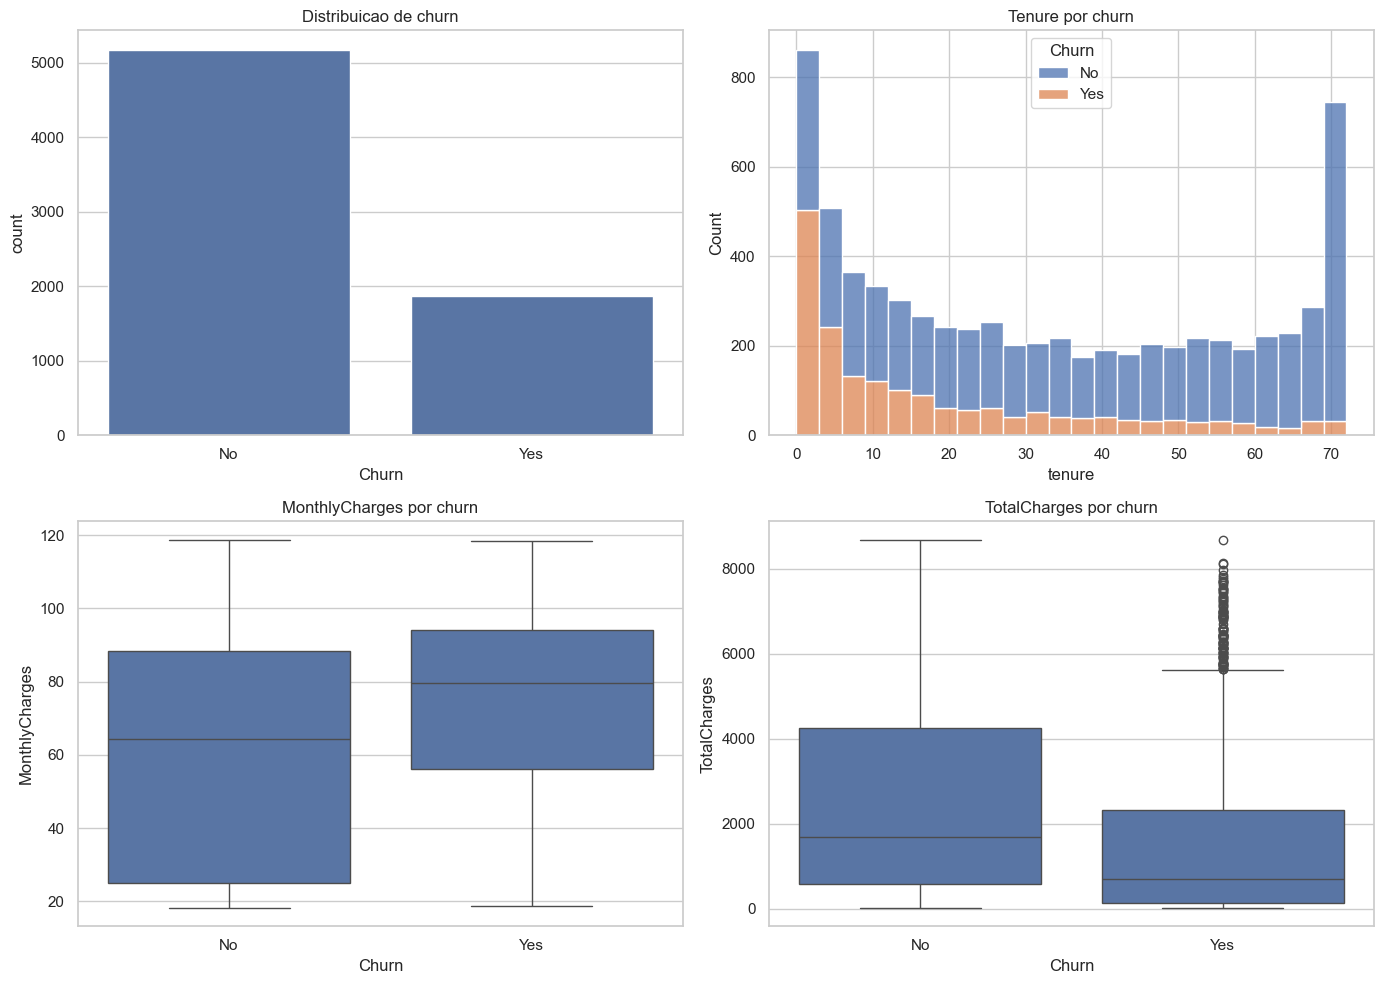

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df, x="Churn", ax=axes[0, 0])
axes[0, 0].set_title("Distribuicao de churn")

sns.histplot(data=df, x="tenure", hue="Churn", multiple="stack", bins=24, ax=axes[0, 1])
axes[0, 1].set_title("Tenure por churn")

sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=axes[1, 0])
axes[1, 0].set_title("MonthlyCharges por churn")

sns.boxplot(data=df, x="Churn", y="TotalCharges", ax=axes[1, 1])
axes[1, 1].set_title("TotalCharges por churn")

plt.tight_layout()

In [5]:
def churn_rate_table(dataframe: pd.DataFrame, column: str) -> pd.DataFrame:
    summary = (
        dataframe.groupby(column, dropna=False)
        .agg(clientes=("ChurnFlag", "size"), churn_rate=("ChurnFlag", "mean"))
        .sort_values("churn_rate", ascending=False)
    )
    summary["churn_rate"] = (summary["churn_rate"] * 100).round(2)
    return summary

for col in [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "OnlineSecurity",
    "TechSupport",
    "PaperlessBilling",
]:
    print(f"\n### {col}")
    display(churn_rate_table(df, col))


### Contract


,clientes,churn_rate
Contract,,
Month-to-month,3875,42.71
One year,1473,11.27
Two year,1695,2.83



### InternetService


,clientes,churn_rate
InternetService,,
Fiber optic,3096,41.89
DSL,2421,18.96
No,1526,7.40



### PaymentMethod


...

,clientes,churn_rate
OnlineSecurity,,
No,3498,41.77
Yes,2019,14.61
No internet service,1526,7.40



### TechSupport


,clientes,churn_rate
TechSupport,,
No,3473,41.64
Yes,2044,15.17
No internet service,1526,7.40



### PaperlessBilling


,clientes,churn_rate
PaperlessBilling,,
Yes,4171,33.57
No,2872,16.33


C:\Users\humbe\AppData\Local\Temp\ipykernel_1464\3741596970.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dataframe.groupby(column, dropna=False)


,clientes,churn_rate
tenure_group,,
0-12m,2186,47.44
13-24m,1024,28.71
25-48m,1594,20.39
49-72m,2239,9.51


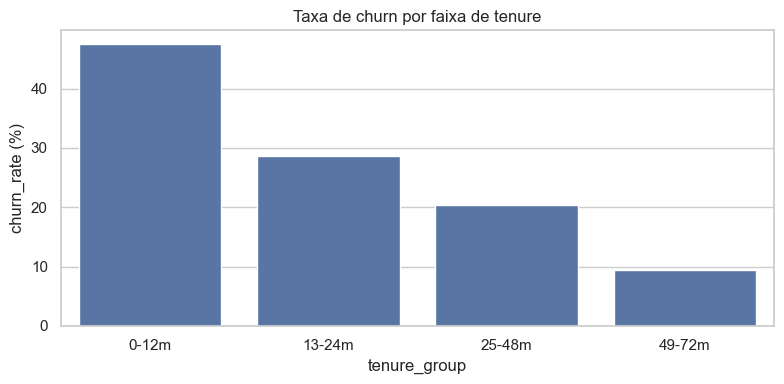

In [6]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12m", "13-24m", "25-48m", "49-72m"],
    include_lowest=True,
)

tenure_summary = churn_rate_table(df, "tenure_group")
display(tenure_summary)

plt.figure(figsize=(8, 4))
sns.barplot(x=tenure_summary.index.astype(str), y=tenure_summary["churn_rate"])
plt.title("Taxa de churn por faixa de tenure")
plt.xlabel("tenure_group")
plt.ylabel("churn_rate (%)")
plt.tight_layout()

## Baseline modelavel

A ideia aqui nao e tunar. E responder rapidamente se o dataset tem sinal preditivo suficiente para justificar um pipeline mais robusto.


In [7]:
target = "ChurnFlag"
X = df.drop(columns=["Churn", target])
y = df[target]

X_train_full, X_test_full, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

threshold_grid = np.arange(0.20, 0.81, 0.05)


def train_and_log_variant(variant_name: str, drop_columns: list[str] | None = None) -> dict:
    drop_columns = drop_columns or []

    X_train_variant = X_train_full.drop(columns=drop_columns, errors="ignore").copy()
    X_test_variant = X_test_full.drop(columns=drop_columns, errors="ignore").copy()

    numeric_features = X_train_variant.select_dtypes(include=["number"]).columns.tolist()
    categorical_features = X_train_variant.select_dtypes(exclude=["number"]).columns.tolist()

    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_features),
            ("cat", categorical_pipeline, categorical_features),
        ]
    )

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
            ),
        ]
    )

    with mlflow.start_run(experiment_id=experiment_id, run_name=f"logreg_{variant_name}") as run:
        mlflow.set_tags(
            {
                "dataset": DATA_PATH.name,
                "notebook": "01_hypothesis_screening.ipynb",
                "model_family": "logistic_regression",
                "feature_variant": variant_name,
            }
        )
        mlflow.log_params(
            {
                "test_size": 0.2,
                "random_state": 42,
                "classifier": "LogisticRegression",
                "classifier__max_iter": 2000,
                "classifier__class_weight": "balanced",
                "dropped_columns": ",".join(drop_columns) if drop_columns else "none",
                "numeric_feature_count": len(numeric_features),
                "categorical_feature_count": len(categorical_features),
            }
        )

        model.fit(X_train_variant, y_train)
        y_pred = model.predict(X_test_variant)
        y_score = model.predict_proba(X_test_variant)[:, 1]

        report_dict = classification_report(y_test, y_pred, digits=3, output_dict=True)
        roc_auc = roc_auc_score(y_test, y_score)
        accuracy = accuracy_score(y_test, y_pred)

        mlflow.log_metrics(
            {
                "accuracy": accuracy,
                "roc_auc": roc_auc,
                "churn_precision": report_dict["1"]["precision"],
                "churn_recall": report_dict["1"]["recall"],
                "churn_f1": report_dict["1"]["f1-score"],
            }
        )

        feature_names = model.named_steps["preprocessor"].get_feature_names_out()
        coefficients = model.named_steps["classifier"].coef_[0]
        coef_df = (
            pd.DataFrame({"feature": feature_names, "coef": coefficients})
            .assign(abs_coef=lambda d: d["coef"].abs())
            .sort_values("abs_coef", ascending=False)
        )
        top_coef_df = coef_df.head(15)

        threshold_rows = []
        for threshold in threshold_grid:
            pred = (y_score >= threshold).astype(int)
            tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
            threshold_rows.append(
                {
                    "threshold": round(threshold, 2),
                    "precision": precision_score(y_test, pred, zero_division=0),
                    "recall": recall_score(y_test, pred, zero_division=0),
                    "f1": f1_score(y_test, pred, zero_division=0),
                    "false_positives": fp,
                    "false_negatives": fn,
                    "predicted_positive_rate": pred.mean(),
                }
            )

        threshold_df = pd.DataFrame(threshold_rows)
        best_f1_row = threshold_df.loc[threshold_df["f1"].idxmax()]
        mlflow.log_metrics(
            {
                "best_threshold_by_f1": float(best_f1_row["threshold"]),
                "best_threshold_precision": float(best_f1_row["precision"]),
                "best_threshold_recall": float(best_f1_row["recall"]),
                "best_threshold_f1": float(best_f1_row["f1"]),
            }
        )

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0], colorbar=False)
        axes[0].set_title(f"Confusion matrix: {variant_name}")
        RocCurveDisplay.from_predictions(y_test, y_score, ax=axes[1])
        axes[1].set_title(f"ROC curve: {variant_name}")
        plt.tight_layout()
        mlflow.log_figure(fig, f"figures/{variant_name}_evaluation_overview.png")
        plt.close(fig)

        fig, ax = plt.subplots(figsize=(10, 6))
        sns.barplot(data=top_coef_df, y="feature", x="coef", ax=ax)
        ax.set_title(f"Top 15 coeficientes: {variant_name}")
        plt.tight_layout()
        mlflow.log_figure(fig, f"figures/{variant_name}_top_coefficients.png")
        plt.close(fig)

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        axes[0].plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="precision")
        axes[0].plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="recall")
        axes[0].plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="f1")
        axes[0].set_title(f"Trade-off por threshold: {variant_name}")
        axes[0].set_xlabel("threshold")
        axes[0].set_ylabel("score")
        axes[0].legend()

        axes[1].plot(threshold_df["threshold"], threshold_df["false_positives"], marker="o", label="false_positives")
        axes[1].plot(threshold_df["threshold"], threshold_df["false_negatives"], marker="o", label="false_negatives")
        axes[1].set_title(f"Erros por threshold: {variant_name}")
        axes[1].set_xlabel("threshold")
        axes[1].set_ylabel("quantidade")
        axes[1].legend()
        plt.tight_layout()
        mlflow.log_figure(fig, f"figures/{variant_name}_threshold_tradeoff.png")
        plt.close(fig)

        mlflow.sklearn.log_model(model, artifact_path="model")

        return {
            "run_id": run.info.run_id,
            "variant_name": variant_name,
            "drop_columns": drop_columns,
            "model": model,
            "y_pred": y_pred,
            "y_score": y_score,
            "report_dict": report_dict,
            "roc_auc": roc_auc,
            "accuracy": accuracy,
            "coef_df": coef_df,
            "top_coef_df": top_coef_df,
            "threshold_df": threshold_df,
            "best_f1_row": best_f1_row,
        }


mlflow.end_run()


variant_configs = [
    {"variant_name": "with_tenure_group", "drop_columns": []},
    {"variant_name": "without_tenure_group", "drop_columns": ["tenure_group"]},
]

variant_results = {
    config["variant_name"]: train_and_log_variant(**config) for config in variant_configs
}

comparison_df = pd.DataFrame(
    [
        {
            "variant": result["variant_name"],
            "run_id": result["run_id"],
            "dropped_columns": ",".join(result["drop_columns"]) if result["drop_columns"] else "none",
            "accuracy": result["accuracy"],
            "roc_auc": result["roc_auc"],
            "churn_precision": result["report_dict"]["1"]["precision"],
            "churn_recall": result["report_dict"]["1"]["recall"],
            "churn_f1": result["report_dict"]["1"]["f1-score"],
            "best_threshold_by_f1": result["best_f1_row"]["threshold"],
            "best_threshold_f1": result["best_f1_row"]["f1"],
        }
        for result in variant_results.values()
    ]
).sort_values("variant")

selected_variant = "without_tenure_group"
selected_result = variant_results[selected_variant]
model = selected_result["model"]
y_pred = selected_result["y_pred"]
y_score = selected_result["y_score"]
coef_df = selected_result["coef_df"]
top_coef_df = selected_result["top_coef_df"]
threshold_df = selected_result["threshold_df"]
best_f1_row = selected_result["best_f1_row"]
selected_run_id = selected_result["run_id"]
selected_roc_auc = selected_result["roc_auc"]

print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")
print(f"MLflow DB path: {MLFLOW_DB_PATH}")
print(f"MLflow artifacts path: {MLFLOW_ARTIFACTS_PATH}")
print(f"MLflow experiment: {MLFLOW_EXPERIMENT_NAME}")
display(comparison_df)
print()
print(
    "O restante do notebook usa a variante 'without_tenure_group' para interpretacao, "
    "mas as duas runs foram registradas no MLflow para comparacao."
)
print(f"Run selecionada: {selected_run_id}")
print("ROC AUC da variante selecionada:", round(selected_roc_auc, 4))
print()
print(classification_report(y_test, y_pred, digits=3))

2026/03/22 16:32:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/22 16:32:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/22 16:32:37 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/22 16:32:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/22 16:32:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, wh

MLflow tracking URI: sqlite:///E:/projetos/churn_model/mlflow.db
MLflow DB path: E:\projetos\churn_model\mlflow.db
MLflow artifacts path: E:\projetos\churn_model\mlartifacts
MLflow experiment: telco-churn-hypothesis-screening


,variant,run_id,dropped_columns,accuracy,roc_auc,churn_precision,churn_recall,churn_f1,best_threshold_by_f1,best_threshold_f1
0,with_tenure_group,ec248ae5528d4fa9810e681c17505ffd,none,0.73,0.84,0.50,0.79,0.61,0.60,0.63
1,without_tenure_group,10b53eeb623f44ed9d941ae01ee808f6,tenure_group,0.74,0.84,0.50,0.78,0.61,0.55,0.62



O restante do notebook usa a variante 'without_tenure_group' para interpretacao, mas as duas runs foram registradas no MLflow para comparacao.
Run selecionada: 10b53eeb623f44ed9d941ae01ee808f6
ROC AUC da variante selecionada: 0.8413

              precision    recall  f1-score   support

           0      0.902     0.722     0.802      1035
           1      0.504     0.783     0.614       374

    accuracy                          0.738      1409
   macro avg      0.703     0.753     0.708      1409
weighted avg      0.797     0.738     0.752      1409



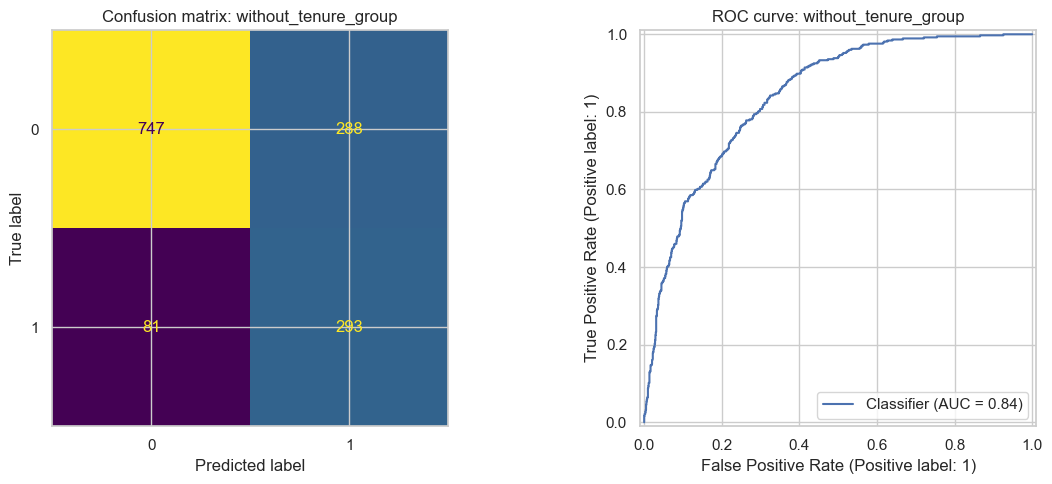

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0], colorbar=False)
axes[0].set_title(f"Confusion matrix: {selected_variant}")

RocCurveDisplay.from_predictions(y_test, y_score, ax=axes[1])
axes[1].set_title(f"ROC curve: {selected_variant}")

plt.tight_layout()

,feature,coef,abs_coef
1,num__tenure,-1.12,1.12
38,cat__Contract_Two year,-0.78,0.78
16,cat__InternetService_Fiber optic,0.71,0.71
2,num__MonthlyCharges,-0.66,0.66
36,cat__Contract_Month-to-month,0.66,0.66
15,cat__InternetService_DSL,-0.62,0.62
3,num__TotalCharges,0.46,0.46
35,cat__StreamingMovies_Yes,0.27,0.27
25,cat__DeviceProtection_No internet service,-0.27,0.27
17,cat__InternetService_No,-0.27,0.27


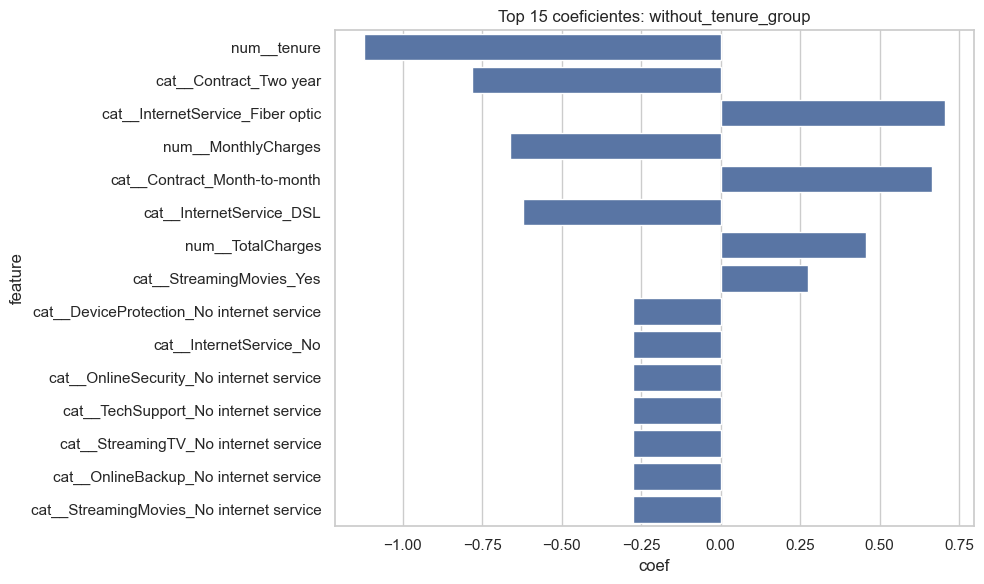

In [9]:
top_coef_df = coef_df.head(15)
display(top_coef_df)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top_coef_df, y="feature", x="coef", ax=ax)
ax.set_title(f"Top 15 coeficientes: {selected_variant}")
plt.tight_layout()

## Como interpretar estes resultados

### Leitura de negocio

- As hipoteses principais foram confirmadas: churn e muito maior entre clientes `Month-to-month`, com baixo `tenure`, `Fiber optic` e sem `OnlineSecurity` ou `TechSupport`.
- Isso significa que o cancelamento nao parece aleatorio. Ha grupos bem mais arriscados, o que justifica seguir para modelagem mais seria.

### Leitura do baseline

- `ROC AUC` acima de `0.80` indica que o modelo separa bem clientes com maior e menor risco de churn.
- Se `recall` da classe `1` estiver alto e `precision` mais baixo, o modelo esta capturando a maior parte dos churners, mas com muitos falsos positivos.
- Para churn, isso costuma ser aceitavel quando a empresa prefere abordar mais clientes do que deixar churners escaparem.

### Cuidado com a acuracia

- Como o target e desbalanceado, a `accuracy` sozinha engana. O mais importante aqui e olhar `recall`, `precision`, `f1-score` e `ROC AUC`.

### Cuidado com os coeficientes

- Os coeficientes ajudam na leitura direcional, mas nao devem ser tratados como explicacao causal direta.
- Agora existem duas runs comparaveis no MLflow: com e sem `tenure_group` no treino.
- Para interpretar coeficientes, a leitura principal do notebook passa a usar a variante sem `tenure_group`, porque ela reduz redundancia com `tenure`.


,threshold,precision,recall,f1,false_positives,false_negatives,predicted_positive_rate
0,0.20,0.39,0.96,0.55,566,14,0.66
1,0.25,0.41,0.94,0.57,510,23,0.61
2,0.30,0.43,0.93,0.59,462,27,0.57
3,0.35,0.45,0.91,0.60,418,35,0.54
4,0.40,0.47,0.87,0.61,371,50,0.49
5,0.45,0.48,0.84,0.61,335,61,0.46
6,0.50,0.50,0.78,0.61,288,81,0.41
7,0.55,0.52,0.75,0.62,255,93,0.38
8,0.60,0.54,0.71,0.61,225,110,0.35
9,0.65,0.57,0.67,0.61,190,125,0.31


Melhor F1 na grade: threshold=0.55, precision=0.524, recall=0.751, f1=0.618


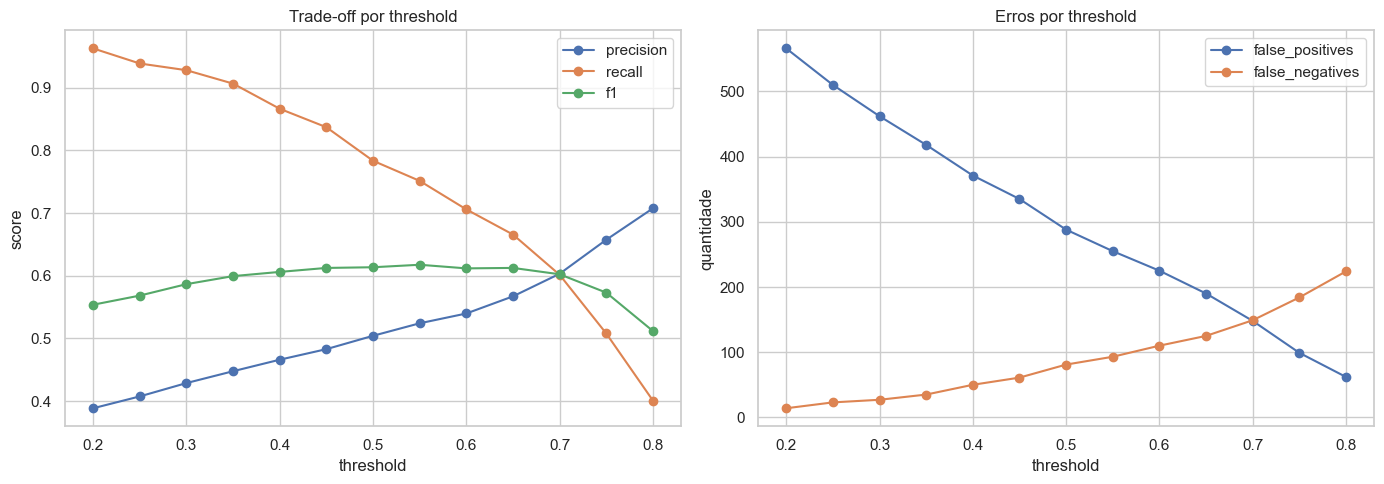

In [10]:
display(threshold_df)

print(
    f"Melhor F1 na grade: threshold={best_f1_row['threshold']:.2f}, "
    f"precision={best_f1_row['precision']:.3f}, "
    f"recall={best_f1_row['recall']:.3f}, "
    f"f1={best_f1_row['f1']:.3f}"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="precision")
axes[0].plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="recall")
axes[0].plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="f1")
axes[0].set_title("Trade-off por threshold")
axes[0].set_xlabel("threshold")
axes[0].set_ylabel("score")
axes[0].legend()

axes[1].plot(threshold_df["threshold"], threshold_df["false_positives"], marker="o", label="false_positives")
axes[1].plot(threshold_df["threshold"], threshold_df["false_negatives"], marker="o", label="false_negatives")
axes[1].set_title("Erros por threshold")
axes[1].set_xlabel("threshold")
axes[1].set_ylabel("quantidade")
axes[1].legend()

plt.tight_layout()